In [16]:
# import libraries
from data_registry import datasets
import pandas as pd
import numpy as np
from statsmodels.gam.api import GLMGam
from statsmodels.gam.api import BSplines
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

# utils functions
from utils.mainutil import to_ts
from utils.m1util import get_spline

# internal plot functions
from plots.ts_plot import ts_plot
from plots.residual_plot import residual_plot
import statsmodels.formula.api as smf

from statsmodels.tsa.stattools import adfuller

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='statsmodels')
warnings.filterwarnings("ignore", category=RuntimeWarning, module='statsmodels')
warnings.filterwarnings("ignore", category=FutureWarning, module='statsmodels')

from sklearn.metrics import mean_squared_error, mean_absolute_error

### Exploratory analysis of the 10 minute temperature data over a period of 1 year.

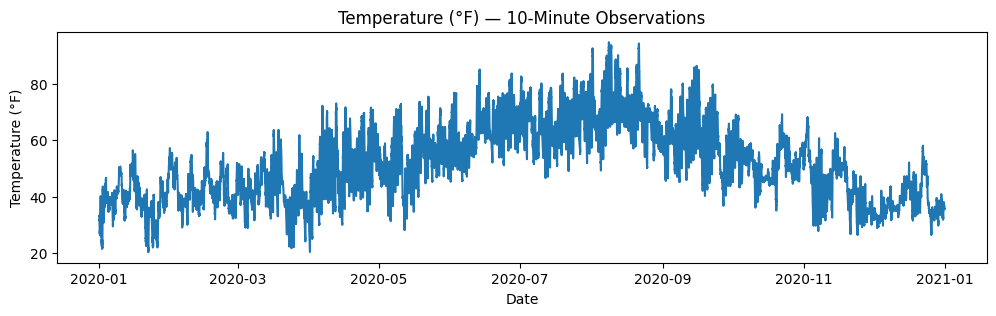

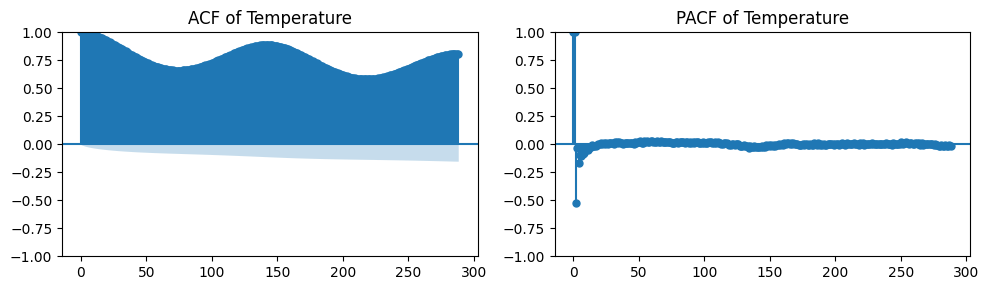

In [8]:
# import weather 10 minute data
filename = datasets.get("weather_10_min")
df = pd.read_csv(filename)

# print(df.columns) - feature to study temperature
df = df[["date", "T (degC)"]].copy()
df.index = pd.to_datetime(df["date"])
df = df.drop(columns="date")

# convert from celsius to farenheit
df["ts"] = df["T (degC)"].apply(lambda x: x * 1.8 + 32)
df = df.drop("T (degC)", axis=1)

fig1 = ts_plot(x=df.index, y=df["ts"], title="Temperature (°F) — 10-Minute Observations", xlabel="Date", ylabel="Temperature (°F)", figsize=(12, 3))

ts = to_ts(df["ts"])

fig, axs = plt.subplots(1, 2, figsize=(10, 3))

plot_acf(ts["ts"] , lags=144*2, ax=axs[0])
axs[0].set_title("ACF of Temperature")

plot_pacf(ts["ts"] , lags=144*2, ax=axs[1], method="ywm")
axs[1].set_title("PACF of Temperature")

plt.tight_layout()
plt.show()

Observations:

The temperature data exhibits both trend and seasonality. There is a clear pattern where the temperature increases until around the end of August and then starts to decrease again, which is expected for regions located above the equator. On the other hand, the ACF plot shows clear seasonal patterns, specifically peaking at lags of around 144. Since the data is recorded every 10 minutes, this corresponds to one full day. This indicates that the temperature at a given time of day is strongly correlated with the temperature at the same time on the previous day, which confirms the presence of daily seasonality.

The PACF plot shows a strong spike at lag 1, followed by a rapid decay toward zero. This suggests that the temperature series has strong short term dependence, where the current value is highly influenced by the immediately previous observation.

### Remove day of the year trend from the temperature data. 

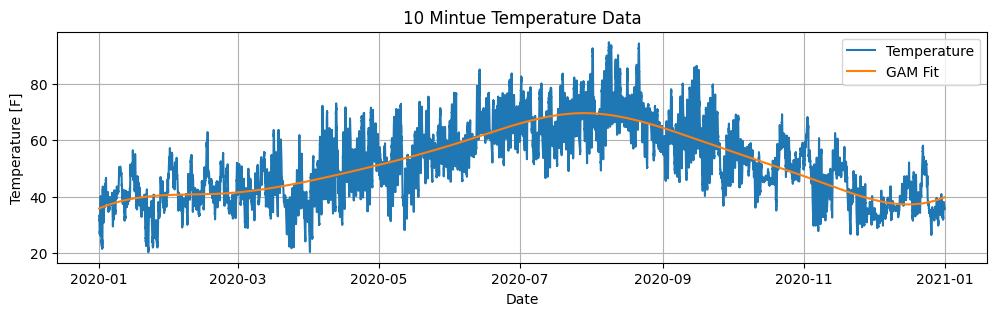

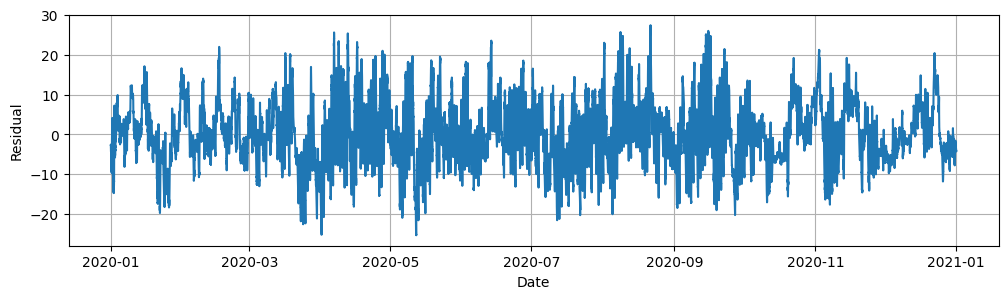

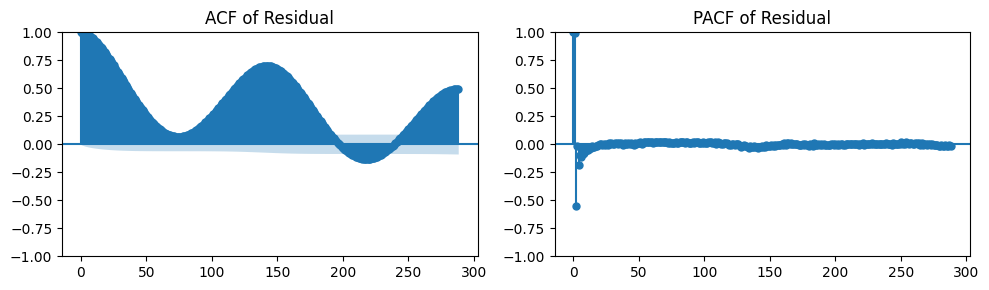

In [9]:

# Estimate trend using GAM
ts["doy"] = np.arange(len(ts))
splines = BSplines(ts[["pts", "doy"]],df=[20, 10],degree=[3, 3])
gam_model = GLMGam.from_formula("ts ~ 1",data=ts,smoother=splines,alpha=[10, 10],family=sm.families.Gaussian()).fit()

# Fit + Residual values
ts["gam_fit"] = gam_model.fittedvalues
ts["gam_res"] = ts["ts"] - ts["gam_fit"]

# Data + Trends Plot
fig = plt.figure(figsize=(12, 3))
plt.plot(ts.index, ts["ts"], label="Temperature")
plt.plot(ts.index, ts["gam_fit"], label="GAM Fit")
plt.title("10 Mintue Temperature Data")
plt.ylabel("Temperature [F]")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.show()

# Residual Plots
plt.figure(figsize=(12,3))
plt.plot(ts["gam_res"] )
plt.xlabel("Date")
plt.ylabel("Residual")
plt.grid(True)
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(10, 3))

plot_acf(ts["gam_res"] , lags=144*2, ax=axs[0])
axs[0].set_title("ACF of Residual")

plot_pacf(ts["gam_res"] , lags=144*2, ax=axs[1], method="ywm")
axs[1].set_title("PACF of Residual")

plt.tight_layout()
plt.show()


Observations:

A GAM model was fit on the data to capture the yearly temperature trend. The residuals show that the trend was clearly removed from the temperature data, as they appear to fluctuate around a constant mean. Naturally, the ACF still exhibits a time of day seasonal pattern, with peaks at lags of around 144, indicating that daily seasonality remains in the data. In addition, the PACF still shows short term dependence, with a noticeable spike at lag 1.

### Remove monthly and time of day seasonal pattern from the temperature data. 

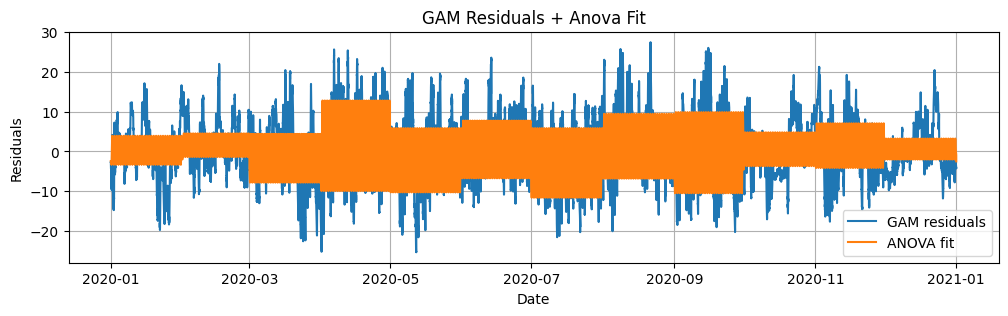

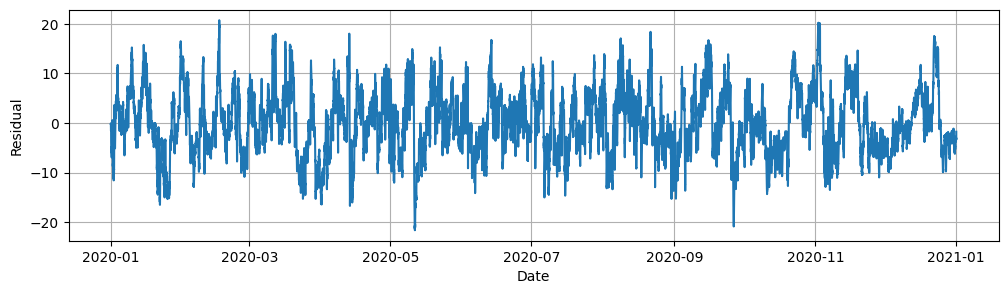

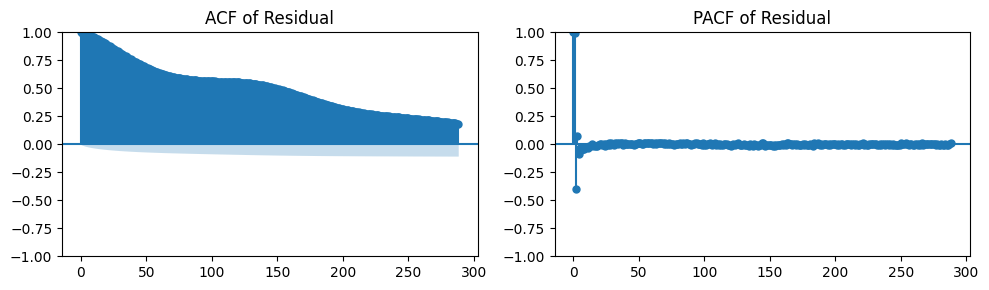

In [10]:
ts["month"] = ts.index.month
ts["tod"] = (ts.index.hour * 60 + ts.index.minute) / 10
anova_model = smf.ols("gam_res ~ C(month):C(tod) - 1", data=ts).fit()

ts["anova_fit"] = anova_model.fittedvalues
ts["anova_res"] = ts["gam_res"] - ts["anova_fit"]

# Data Plots
fig = plt.figure(figsize=(12, 3))
plt.plot(ts.index, ts["gam_res"], label="GAM residuals")
plt.plot(ts.index, ts["anova_fit"], label="ANOVA fit")
plt.title("GAM Residuals + Anova Fit")
plt.ylabel("Residuals")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.show()

# Residual Plots
plt.figure(figsize=(12,3))
plt.plot(ts["anova_res"] )
plt.xlabel("Date")
plt.ylabel("Residual")
plt.grid(True)
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(10, 3))

plot_acf(ts["anova_res"] , lags=144*2, ax=axs[0])
axs[0].set_title("ACF of Residual")

plot_pacf(ts["anova_res"] , lags=144*2, ax=axs[1], method="ywm")
axs[1].set_title("PACF of Residual")

plt.tight_layout()
plt.show()

Observations:

An ANOVA model using the month and time of day was fitted on the GAM residuals. From the ANOVA model values, the seasonal patterns appear to change throughout the year. The residual values appear to fluctuate around a constant mean. Based on the ACF plots, it appears that the seasonal spikes have been removed from the data, indicating that the month and time of day captured the main seasonal components of the series. On the other hand, the PACF still shows a large spike at lag 1, indicating that some short term persistence still remains in the data.

### ARIMA Model

In [11]:
def find_best_arima(series, p_max, d, q_max):

    max_ar=list(range(0,p_max))
    max_ma=list(range(0,q_max))
    
    aicc_matrix = np.full((len(max_ar), len(max_ma)), np.inf)
    bic_matrix  = np.full((len(max_ar), len(max_ma)), np.inf)
    
    n = len(series)
    
    for p in max_ar:
        for q in max_ma:
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    fit_result = ARIMA(series, order=(p, d, q)).fit()
    
                k = len(fit_result.params)
                aicc = fit_result.aic + (2 * k**2 + 2 * k) / (n - k - 1)
                bic = fit_result.bic
    
                aicc_matrix[p, q] = aicc
                bic_matrix[p, q]  = bic
                
            except Exception:
                # Skip failed fits silently
                pass

    p_best_aicc, q_best_aicc = np.unravel_index(np.argmin(aicc_matrix), aicc_matrix.shape)
    best_aicc = aicc_matrix[p_best_aicc, q_best_aicc]

    p_best_bic, q_best_bic = np.unravel_index(np.argmin(bic_matrix), bic_matrix.shape)
    best_bic = bic_matrix[p_best_bic, q_best_bic]
    
    print("Best by AICc:", (p_best_aicc, d, q_best_aicc), "AICc:", best_aicc)
    print("Best by BIC :", (p_best_bic,  d, q_best_bic),  "BIC :", best_bic)

    # return {
    #     "aicc_order": (p_best_aicc, d, q_best_aicc),
    #     "bic_order":  (p_best_bic,  d, q_best_bic),
    #     "aicc_matrix": aicc_matrix,
    #     "bic_matrix": bic_matrix
    # }

In [82]:
p_max = 5
d_max = 0
q_max = 5
find_best_arima(ts["anova_res"], p_max, d_max, q_max)

Best by AICc: (np.int64(3), 0, np.int64(4)) AICc: 41241.643080242866
Best by BIC : (np.int64(3), 0, np.int64(4)) BIC : 41321.49031724838


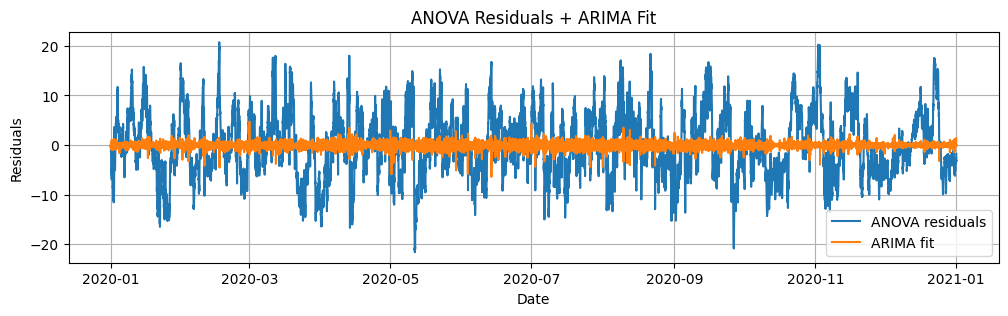

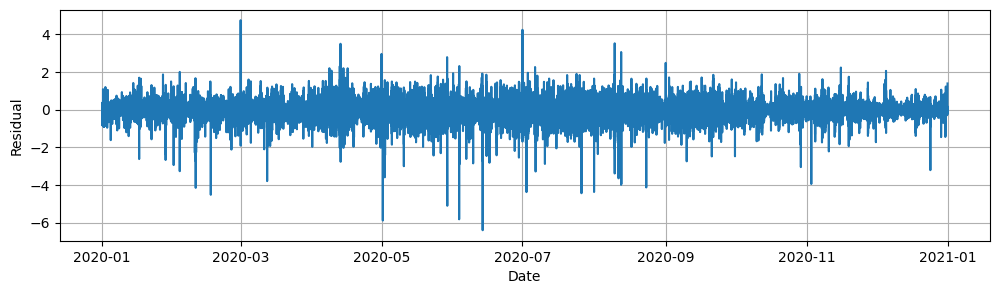

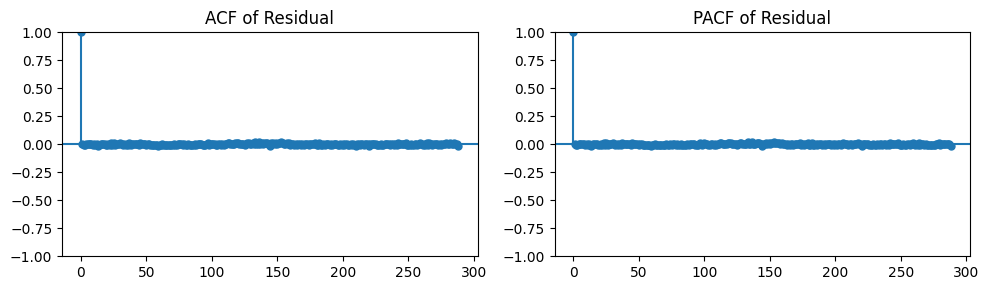

ARIMA Residuals: p-value: 0.0


In [12]:
arima_model = ARIMA(ts["anova_res"], order=(3, 0, 4)).fit()

ts["arima_fit"] = arima_model.fittedvalues
ts["arima_res"] = ts["anova_res"] - ts["arima_fit"]

# Data Plots
fig = plt.figure(figsize=(12, 3))
plt.plot(ts.index, ts["anova_res"], label="ANOVA residuals")
plt.plot(ts.index, ts["arima_res"], label="ARIMA fit")
plt.title("ANOVA Residuals + ARIMA Fit")
plt.ylabel("Residuals")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.show()

# Residual Plots
plt.figure(figsize=(12,3))
plt.plot(ts["arima_res"] )
plt.xlabel("Date")
plt.ylabel("Residual")
plt.grid(True)
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(10, 3))

plot_acf(ts["arima_res"] , lags=144*2, ax=axs[0])
axs[0].set_title("ACF of Residual")

plot_pacf(ts["arima_res"] , lags=144*2, ax=axs[1], method="ywm")
axs[1].set_title("PACF of Residual")

plt.tight_layout()
plt.show()


result = adfuller(ts["arima_res"].dropna())

print("ARIMA Residuals: p-value:", result[1])


Observations:

The ADF test shows a very small p-value (p ≈ 0), which indicates that the ARIMA residuals are stationary, meaning there is no remaining unit root behavior in the series. In addition, the ACF and PACF plots of the residuals are approximately flat, suggesting that most of the autocorrelation and persistence have been successfully captured by the model.

Using AICc and BIC for model selection, both criteria suggest an ARIMA(3,0,4) model, which provides the best fit among the candidates considered. This indicates that the model is able to adequately capture the remaining temporal dependence in the data after removing trend and seasonality.

In [13]:
def rolling_gam_anova_arima_1step(train_df, test_df, arima_order):
    idx = test_df.index
    preds = []

    # GAM
    full_df = pd.concat([train_df, test_df]).copy()
    full_df["doy"] = np.arange(len(full_df))

    n_train = len(train_df)

    train_df["doy"] = np.arange(n_train)
    test_df["doy"] = np.arange(n_train, n_train + len(test_df))
    
    
    splines = BSplines(train_df[["pts", "doy"]],df=[20, 10],degree=[3, 3],knot_kwds=[
            {
                "lower_bound": full_df["pts"].min(),
                "upper_bound": full_df["pts"].max()
            },
            {
                "lower_bound": full_df["doy"].min(),
                "upper_bound": full_df["doy"].max()
            }
        ]
    )
    gam_model = GLMGam.from_formula("ts ~ 1", data=train_df, smoother=splines, alpha=[10, 10], family=sm.families.Gaussian()).fit()

    train_df["gam_fit"] = gam_model.fittedvalues
    train_df["gam_res"] = train_df["ts"] - train_df["gam_fit"]

    # ANOVA
    train_df["month"] = train_df.index.month
    train_df["tod"] = ((train_df.index.hour * 60 + train_df.index.minute) / 10).astype(int)

    anova_model = smf.ols("gam_res ~ C(month):C(tod) - 1", data=train_df).fit()

    train_df["anova_fit"] = anova_model.fittedvalues
    train_df["anova_res"] = train_df["gam_res"] - train_df["anova_fit"]

    history = train_df

    for f in range(len(test_df)):
        # Fit ARIMA on remaining residuals
        arima_model = ARIMA(history["anova_res"], order=arima_order, trend="n").fit()

        arima_forecast = arima_model.get_forecast(steps=1).predicted_mean.iloc[0]


        # GAM forecast
        next_row = test_df.iloc[[f]]
        next_row["doy"] = len(history)
        gam_forecast = gam_model.predict(exog=pd.DataFrame({"Intercept": [1]}, index=next_row.index),exog_smooth=next_row[["pts", "doy"]]).iloc[0]

        # ANOVA forecast
        next_season = pd.DataFrame(index=next_row.index)
        next_season["month"] = next_row.index.month
        next_season["tod"] = ((next_row.index.hour * 60 + next_row.index.minute) / 10).astype(int)

        anova_forecast = anova_model.predict(next_season).iloc[0]

        final_forecast = gam_forecast + anova_forecast + arima_forecast

        preds.append(final_forecast)

        # 5. Add true observed test point to history
        history = pd.concat([history, test_df.iloc[[f]]])

    return pd.Series(preds, index=idx)

In [14]:
train_df = ts.iloc[:-144]
test_df  = ts.iloc[-144:]

pred_series = rolling_gam_anova_arima_1step(train_df, test_df, arima_order=(3,0,4))
pred_series.to_csv("predictions.csv")

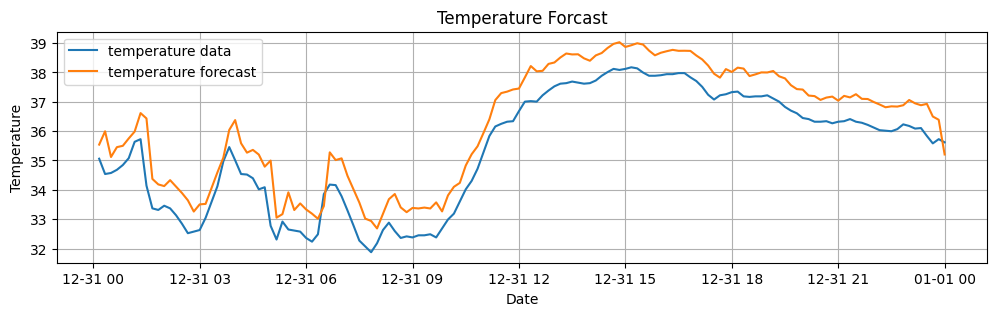

In [ ]:
fig = plt.figure(figsize=(12, 3))
plt.plot(test_df.index, test_df["ts"], label="temperature data")
plt.plot(pred_series, label="temperature forecast")
plt.title("Temperature Forcast")
plt.ylabel("Temperature")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.show()


In [20]:
def evaluate_performance(true, pred, model_name="Model"):
    mspe = mean_squared_error(true, pred)
    mae = mean_absolute_error(true, pred)
    mape = np.mean(np.abs((true - pred) / (true + 1e-6)))
    pm = (np.sum((true+1e-6 - pred) ** 2) / np.sum((true+1e-6 - np.mean(true)) ** 2))

    print(f"=== {model_name} Performance ===")
    print(f"MSPE: {mspe:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"MAPE: {mape:.4f}")
    print(f"PM:   {pm:.4f}")
    print("-" * 40)

evaluate_performance(test_df["ts"], pred_series, model_name="Model")


=== Model Performance ===
MSPE: 0.8158
MAE:  0.8635
MAPE: 0.0245
PM:   0.2104
----------------------------------------
